# EDA of crime reports in Mexico (2015 - 2025)

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from shadowroutes.config import settings

src_path = Path('../')
os.chdir(src_path)

In [2]:
# print("Data root:", settings.DATA_ROOT)
# print(Path.cwd())

## Parameters

In [3]:
# Data paths

# Crime report data (federal law) from SESNSP - obtained in October 2025
data_path_ff = Path(settings.DATA_ROOT / 'sesnsp' / 'raw' / 'Fuero_federal_2012-2015_sep2025.csv')

# Population estimates (mid-year) from CONAPO - obtained in October 2025
data_path_pop = Path(settings.DATA_ROOT / 'conapo' / 'raw' / '0_Pob_Mitad_1950_2070.xlsx')

# Crime report data (common law) from SESNSP - obtained in October 2025
data_path_fc = Path(settings.DATA_ROOT / 'sesnsp' / 'raw' / 'Estatal-Delitos-2015-2025_sep2025.csv')

## Data and pre-processing

### Crime reports (federal law)

In [4]:
data_ff = pd.read_csv(data_path_ff, encoding='latin1')
print(f'File read: {print(data_path_ff.name)}')

print(data_ff.shape)
data_ff.head()

Fuero_federal_2012-2015_sep2025.csv
File read: None
(13398, 18)


,AÑO,INEGI,ENTIDAD,LEY,CONCEPTO,TIPO,ENERO,FEBRERO,MARZO,ABRIL,MAYO,JUNIO,JULIO,AGOSTO,SEPTIEMBRE,OCTUBRE,NOVIEMBRE,DICIEMBRE
0,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,PRODUCCION,0,0,0,0,0,0,0,0,0,0.0,1.0,0.0
1,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRANSPORTE,0,0,0,3,1,3,0,0,0,0.0,2.0,0.0
2,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRAFICO,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0
3,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,COMERCIO,13,9,18,16,8,14,13,6,0,0.0,0.0,0.0
4,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,SUMINISTRO,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0


In [5]:
data_ff.columns = data_ff.columns.str.lower()
data_ff.rename(columns={'año': 'ao', 'inegi': 'cve_geo'}, inplace=True)
data_ff.columns

Index(['ao', 'cve_geo', 'entidad', 'ley', 'concepto', 'tipo', 'enero',
       'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto',
       'septiembre', 'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [6]:
# Check where the inegi entity key is null

nulls_cve_geo = data_ff[data_ff.cve_geo.isnull()]
print(nulls_cve_geo.shape)
print(nulls_cve_geo.entidad.unique())

(406, 18)
['EXTRANJERO']


In [7]:
# Delete rows where the inegi entity key is null
data_ff.dropna(subset=['cve_geo'], inplace=True)
data_ff['cve_geo'] = data_ff['cve_geo'].astype('int64')
print(data_ff.shape)

(12992, 18)


In [8]:
data_ff_melt = pd.melt(data_ff, id_vars=data_ff.columns[:6], var_name='mes', value_name='conteo_delitos')
data_ff_melt.head()

,ao,cve_geo,entidad,ley,concepto,tipo,mes,conteo_delitos
0,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,PRODUCCION,enero,0.0
1,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRANSPORTE,enero,0.0
2,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRAFICO,enero,0.0
3,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,COMERCIO,enero,13.0
4,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,SUMINISTRO,enero,0.0


### Population estimates

In [9]:
data_pop = pd.read_excel(data_path_pop)
print(f'File read: {print(data_path_pop.name)}')

print(data_pop.shape)
data_pop.head()

0_Pob_Mitad_1950_2070.xlsx
File read: None
(737660, 7)


,RENGLON,AÑO,ENTIDAD,CVE_GEO,EDAD,SEXO,POBLACION
0,1,1950,República Mexicana,0,0,Hombres,580871
1,2,1950,República Mexicana,0,0,Mujeres,568159
2,3,1950,República Mexicana,0,1,Hombres,525478
3,4,1950,República Mexicana,0,1,Mujeres,516674
4,5,1950,República Mexicana,0,2,Hombres,492568


In [10]:
data_pop.columns = data_pop.columns.str.lower()
data_pop.rename(columns={'año': 'ao'}, inplace=True)
data_pop['cve_geo'] = data_pop['cve_geo'].astype('int64')
data_pop.columns

Index(['renglon', 'ao', 'entidad', 'cve_geo', 'edad', 'sexo', 'poblacion'], dtype='object')

In [11]:
# Filter data set from 2000 to 2025

years = np.arange(2000, 2026, 1)
pop_filtered = data_pop[data_pop.ao.isin(years)].reset_index(drop=True)

print(pop_filtered.shape)
pop_filtered.head()

(188760, 7)


,renglon,ao,entidad,cve_geo,edad,sexo,poblacion
0,222201,2000,República Mexicana,0,0,Hombres,1222259
1,222202,2000,República Mexicana,0,0,Mujeres,1180786
2,222203,2000,República Mexicana,0,1,Hombres,1208070
3,222204,2000,República Mexicana,0,1,Mujeres,1168285
4,222205,2000,República Mexicana,0,2,Hombres,1195784


In [12]:
df_pop_yearly = pop_filtered.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['poblacion'].sum()
df_pop_yearly

,entidad,ao,cve_geo,poblacion
0,Aguascalientes,2000,1,968833
1,Aguascalientes,2001,1,992461
2,Aguascalientes,2002,1,1017397
3,Aguascalientes,2003,1,1042583
4,Aguascalientes,2004,1,1067693
...,...,...,...,...
853,Zacatecas,2021,32,1655403
854,Zacatecas,2022,32,1667567
855,Zacatecas,2023,32,1683013
856,Zacatecas,2024,32,1698252


### Crime reports (common law)

In [13]:
data_fc = pd.read_csv(data_path_fc, encoding='latin1')
print(f'File read: {print(data_path_fc.name)}')

print(data_fc.shape)
data_fc.head()

Estatal-Delitos-2015-2025_sep2025.csv
File read: None
(34496, 19)


,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,3,0,2,1,1,1,2,1,2,2.0,2.0,1.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,0,0,0,1,0,1,0,0.0,0.0,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,2,2,3,2,0,1,2,0.0,0.0,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,2,0,0,1,0,0,0,0,0,0.0,0.0,0.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0


In [14]:
data_fc.columns = data_fc.columns.str.lower()
data_fc.rename(columns={
    'año': 'ao', 'clave_ent': 'cve_geo', 'bien jurídico afectado': 'bien_juri_afec', 
    'tipo de delito': 'tipo_delito', 'subtipo de delito': 'subtipo_delito'
    }, inplace=True)

data_fc.columns

Index(['ao', 'cve_geo', 'entidad', 'bien_juri_afec', 'tipo_delito',
       'subtipo_delito', 'modalidad', 'enero', 'febrero', 'marzo', 'abril',
       'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre',
       'noviembre', 'diciembre'],
      dtype='object')

In [15]:
data_fc_melt = pd.melt(data_fc, id_vars=data_fc.columns[:7], var_name='mes', value_name='conteo_delitos')
data_fc_melt.head()

,ao,cve_geo,entidad,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,3.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,2.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,enero,0.0


## Organized Crime Reports (Federal Law)

In [16]:
for i in range(0, 6):
    col = data_ff.columns[i]
    print(col)
    print(data_ff[col].unique(), '\n')

ao
[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025] 

cve_geo
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32] 

entidad
['AGUASCALIENTES' 'BAJA CALIFORNIA' 'BAJA CALIFORNIA SUR' 'CAMPECHE'
 'COAHUILA' 'COLIMA' 'CHIAPAS' 'CHIHUAHUA' 'CIUDAD DE MEXICO' 'DURANGO'
 'GUANAJUATO' 'GUERRERO' 'HIDALGO' 'JALISCO' 'MEXICO' 'MICHOACAN'
 'MORELOS' 'NAYARIT' 'NUEVO LEON' 'OAXACA' 'PUEBLA' 'QUERETARO'
 'QUINTANA ROO' 'SAN LUIS POTOSI' 'SINALOA' 'SONORA' 'TABASCO'
 'TAMAULIPAS' 'TLAXCALA' 'VERACRUZ' 'YUCATAN' 'ZACATECAS'] 

ley
['CODIGO PENAL FEDERAL' 'OTRAS LEYES Y CODIGOS'] 

concepto
['CONTRA LA SALUD' 'OTROS DELITOS' 'OTRAS LEYES Y CODIGOS'
 'LEY GENERAL DE SALUD (L.G.S.)'
 'LEY FEDERAL CONTRA LA DELINCUENCIA ORGANIZADA (L.F.C.D.O.)'] 

tipo
['PRODUCCION' 'TRANSPORTE' 'TRAFICO' 'COMERCIO' 'SUMINISTRO' 'POSESION'
 'OTROS' 'COMETIDOS POR SERVIDORES PUBLICOS'
 'CONTRA EL AMBIENTE Y LA GESTION AMBIENTAL'
 'CONTRA LA INTEGRIDAD 

### Counts

In [21]:
df_do = data_ff_melt[data_ff_melt['concepto'] == 'LEY FEDERAL CONTRA LA DELINCUENCIA ORGANIZADA (L.F.C.D.O.)']
df_do_yearly = df_do.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['conteo_delitos'].sum()
df_do_yearly.head()

,entidad,ao,cve_geo,conteo_delitos
0,AGUASCALIENTES,2012,1,42.0
1,AGUASCALIENTES,2013,1,37.0
2,AGUASCALIENTES,2014,1,39.0
3,AGUASCALIENTES,2015,1,28.0
4,AGUASCALIENTES,2016,1,1.0


In [23]:
top10_do = df_do_yearly.groupby('entidad')['conteo_delitos'].sum().nlargest(10).index
df_top10_do = df_do_yearly[df_do_yearly['entidad'].isin(top10_do)]
df_top10_do.entidad.unique()

array(['CIUDAD DE MEXICO', 'COAHUILA', 'GUERRERO', 'JALISCO', 'MEXICO',
       'MICHOACAN', 'MORELOS', 'SINALOA', 'TAMAULIPAS', 'VERACRUZ'],
      dtype=object)

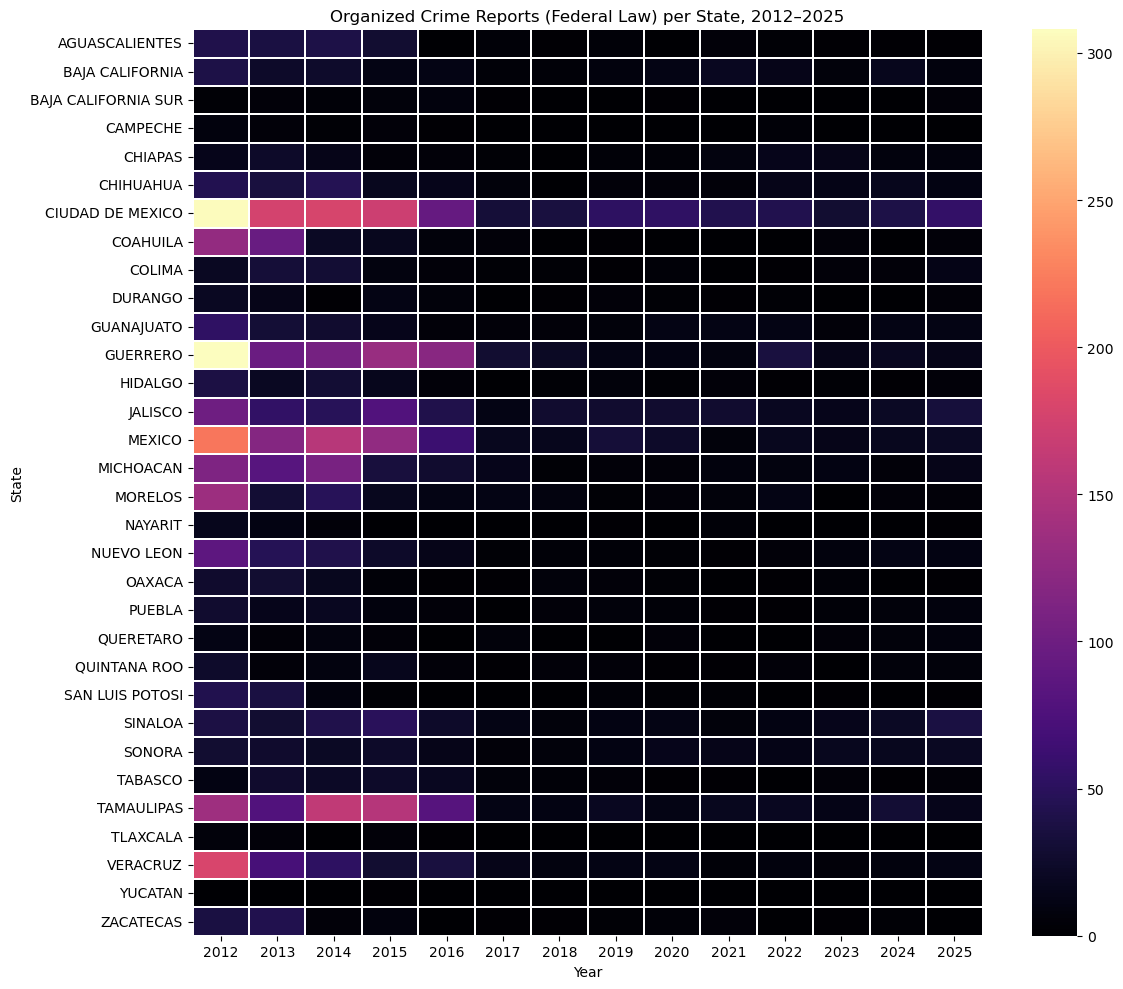

In [24]:
heat_data = df_do_yearly.pivot(index='entidad', columns='ao', values='conteo_delitos').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Organized Crime Reports (Federal Law) per State, 2012–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

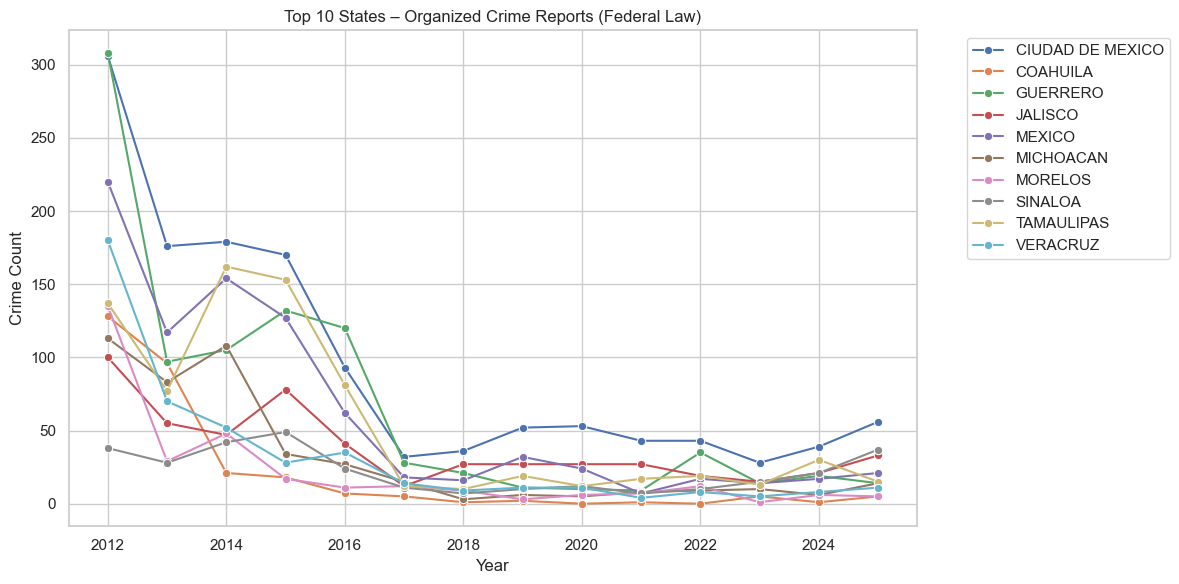

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_do,
    x='ao',
    y='conteo_delitos',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Reports (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [26]:
# Create interactive plot

fig = px.line(
    df_top10_do,
    x='ao',
    y='conteo_delitos',
    color='entidad',
    markers=True,
    title='Top 10 States – Organized Crime Reports (Federal Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Rates per 100k inhabitants

In [27]:
df_do_rates = df_do_yearly.merge(df_pop_yearly.loc[:, ['ao', 'cve_geo', 'poblacion']], on=['cve_geo', 'ao'])
df_do_rates.head(10)

,entidad,ao,cve_geo,conteo_delitos,poblacion
0,AGUASCALIENTES,2012,1,42.0,1265972
1,AGUASCALIENTES,2013,1,37.0,1293332
2,AGUASCALIENTES,2014,1,39.0,1320036
3,AGUASCALIENTES,2015,1,28.0,1344649
4,AGUASCALIENTES,2016,1,1.0,1367412
5,AGUASCALIENTES,2017,1,4.0,1389971
6,AGUASCALIENTES,2018,1,2.0,1413003
7,AGUASCALIENTES,2019,1,4.0,1436338
8,AGUASCALIENTES,2020,1,1.0,1456050
9,AGUASCALIENTES,2021,1,6.0,1472645


In [28]:
df_do_rates['tasa_por_100k'] = df_do_rates['conteo_delitos'] / df_do_rates['poblacion'] * 100000
df_do_rates.head()

,entidad,ao,cve_geo,conteo_delitos,poblacion,tasa_por_100k
0,AGUASCALIENTES,2012,1,42.0,1265972,3.317609
1,AGUASCALIENTES,2013,1,37.0,1293332,2.860828
2,AGUASCALIENTES,2014,1,39.0,1320036,2.954465
3,AGUASCALIENTES,2015,1,28.0,1344649,2.082328
4,AGUASCALIENTES,2016,1,1.0,1367412,0.073131


In [29]:
top10_rates_do = df_do_rates.groupby('entidad')['tasa_por_100k'].sum().nlargest(10).index
df_top10_rates_do = df_do_rates[df_do_rates['entidad'].isin(top10_rates_do)]
df_top10_rates_do.entidad.unique()

array(['AGUASCALIENTES', 'CIUDAD DE MEXICO', 'COAHUILA', 'COLIMA',
       'GUERRERO', 'MICHOACAN', 'MORELOS', 'SINALOA', 'SONORA',
       'TAMAULIPAS'], dtype=object)

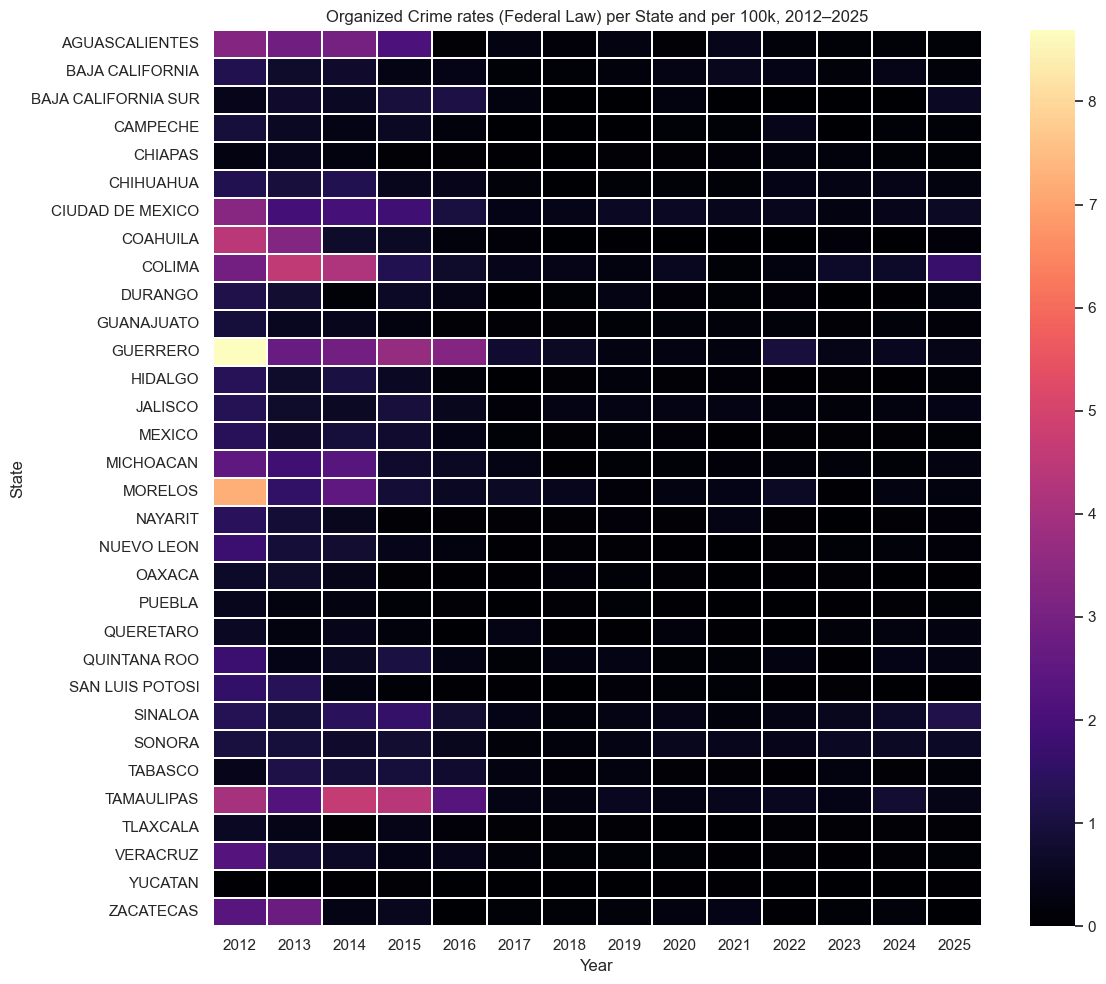

In [30]:
heat_data = df_do_rates.pivot(index='entidad', columns='ao', values='tasa_por_100k').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Organized Crime rates (Federal Law) per State and per 100k, 2012–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

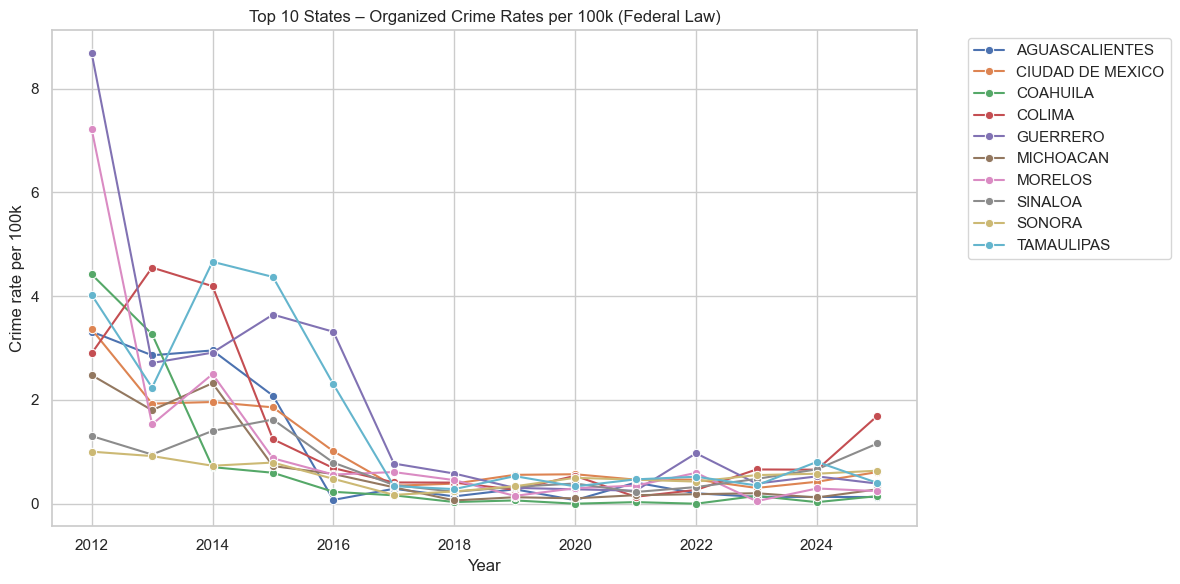

In [31]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_rates_do,
    x='ao',
    y='tasa_por_100k',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Rates per 100k (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime rate per 100k')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


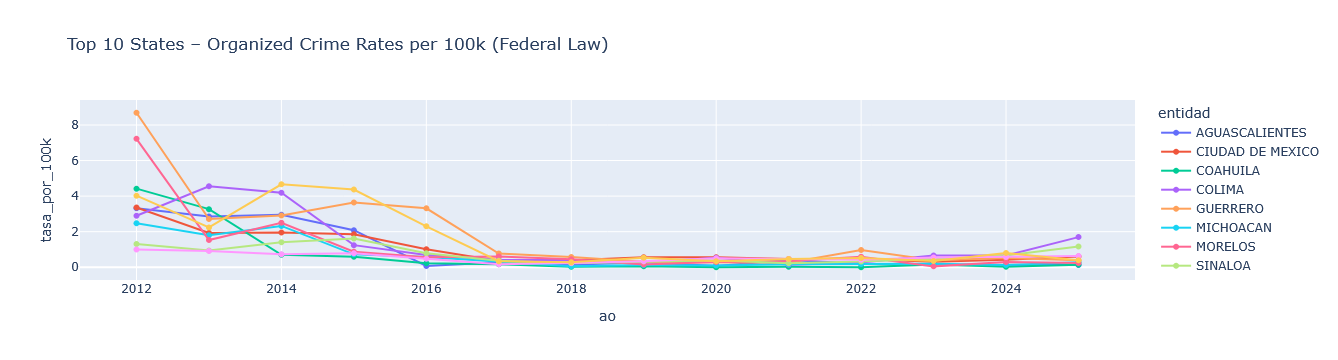

In [32]:
# Create interactive plot

fig = px.line(
    df_top10_rates_do,
    x='ao',
    y='tasa_por_100k',
    color='entidad',
    markers=True,
    title='Top 10 States – Organized Crime Rates per 100k (Federal Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


## Crime Reports (common law)

In [33]:
for i in range(0, 7):
    col = data_fc_melt.columns[i]
    print(col)
    print(data_fc_melt[col].unique(), '\n')

ao
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025] 

cve_geo
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32] 

entidad
['Aguascalientes' 'Baja California' 'Baja California Sur' 'Campeche'
 'Coahuila de Zaragoza' 'Colima' 'Chiapas' 'Chihuahua' 'Ciudad de México'
 'Durango' 'Guanajuato' 'Guerrero' 'Hidalgo' 'Jalisco' 'México'
 'Michoacán de Ocampo' 'Morelos' 'Nayarit' 'Nuevo León' 'Oaxaca' 'Puebla'
 'Querétaro' 'Quintana Roo' 'San Luis Potosí' 'Sinaloa' 'Sonora' 'Tabasco'
 'Tamaulipas' 'Tlaxcala' 'Veracruz de Ignacio de la Llave' 'Yucatán'
 'Zacatecas'] 

bien_juri_afec
['La vida y la Integridad corporal' 'Libertad personal'
 'La libertad y la seguridad sexual' 'El patrimonio' 'La familia'
 'La sociedad' 'Otros bienes jurídicos afectados (del fuero común)'] 

tipo_delito
['Homicidio' 'Lesiones' 'Feminicidio' 'Aborto'
 'Otros delitos que atentan contra la vida y la integridad corporal'
 'Secuestro' 'Tráfico de menores' 'Rapto'
 '

In [34]:
oc_type_crime = ['Homicidio', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo']
oc_subtype_crime = ['Homicidio doloso', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo'] 

data_fc_filtered = data_fc_melt[(data_fc_melt.tipo_delito.isin(oc_type_crime)) & (data_fc_melt.subtipo_delito.isin(oc_subtype_crime))]

for i in range(3, 7):
    col = data_fc_filtered.columns[i]
    print(col)
    print(data_fc_filtered[col].unique(), '\n')

bien_juri_afec
['La vida y la Integridad corporal' 'Libertad personal' 'El patrimonio'
 'La sociedad' 'Otros bienes jurídicos afectados (del fuero común)'] 

tipo_delito
['Homicidio' 'Secuestro' 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 

subtipo_delito
['Homicidio doloso' 'Secuestro' 'Extorsión' 'Trata de personas'
 'Narcomenudeo'] 

modalidad
['Con arma de fuego' 'Con arma blanca' 'Con otro elemento'
 'No especificado' 'Secuestro extorsivo' 'Secuestro con calidad de rehén'
 'Secuestro para causar daño' 'Secuestro exprés' 'Otro tipo de secuestros'
 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 



In [35]:
data_fc_filtered.head()

,ao,cve_geo,entidad,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,3.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,2.0
24,2015,1,Aguascalientes,Libertad personal,Secuestro,Secuestro,Secuestro extorsivo,enero,0.0


In [36]:
df_fc_yearly = data_fc_filtered.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['conteo_delitos'].sum()
df_fc_yearly.head()

,entidad,ao,cve_geo,conteo_delitos
0,Aguascalientes,2015,1,698.0
1,Aguascalientes,2016,1,830.0
2,Aguascalientes,2017,1,1052.0
3,Aguascalientes,2018,1,1941.0
4,Aguascalientes,2019,1,2428.0


### Counts

In [37]:
top10_fc = df_fc_yearly.groupby('entidad')['conteo_delitos'].sum().nlargest(10).index
df_top10_fc = df_fc_yearly[df_fc_yearly['entidad'].isin(top10_fc)]
df_top10_fc.entidad.unique()

array(['Baja California', 'Chihuahua', 'Ciudad de México',
       'Coahuila de Zaragoza', 'Guanajuato', 'Jalisco',
       'Michoacán de Ocampo', 'México', 'Nuevo León', 'Sonora'],
      dtype=object)

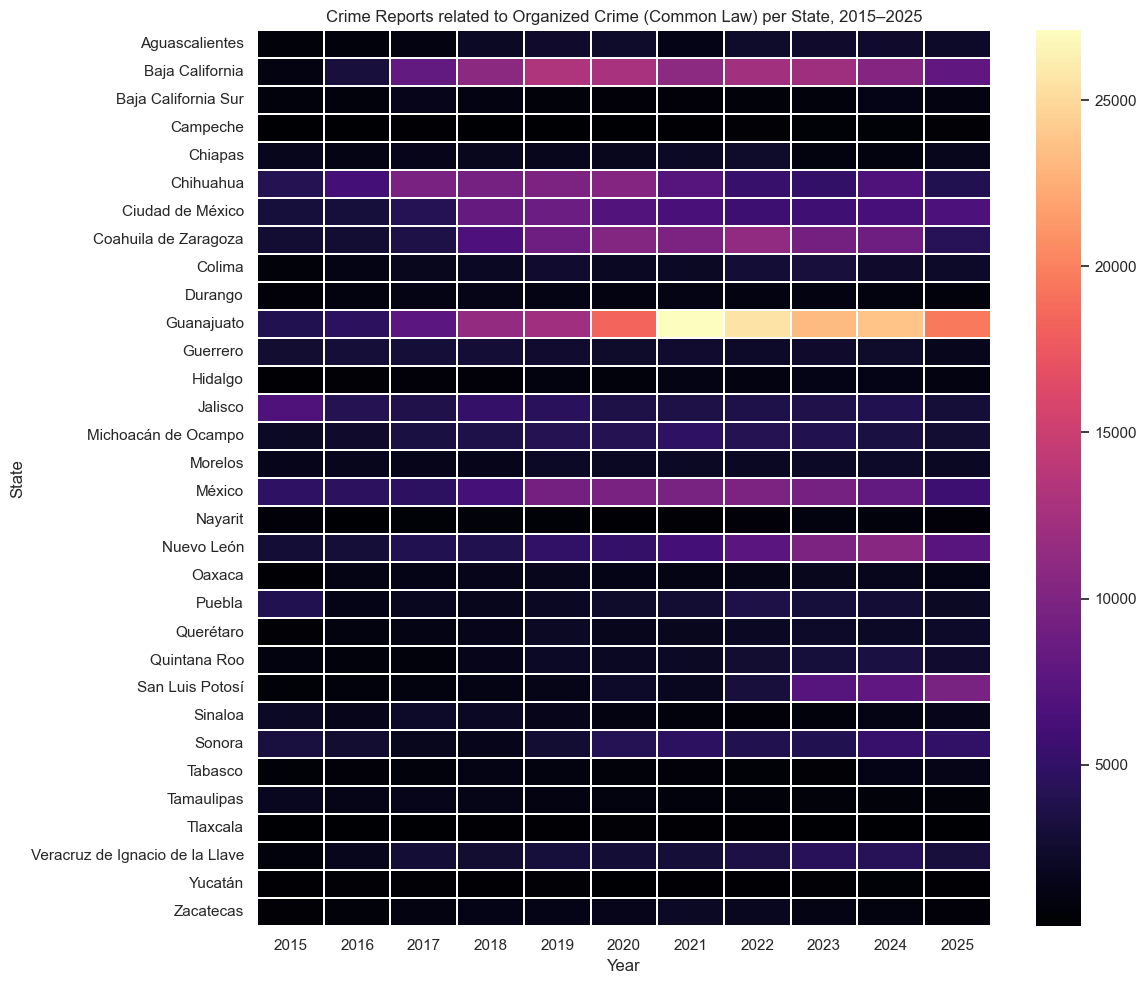

In [38]:
heat_data = df_fc_yearly.pivot(index='entidad', columns='ao', values='conteo_delitos').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime Reports related to Organized Crime (Common Law) per State, 2015–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

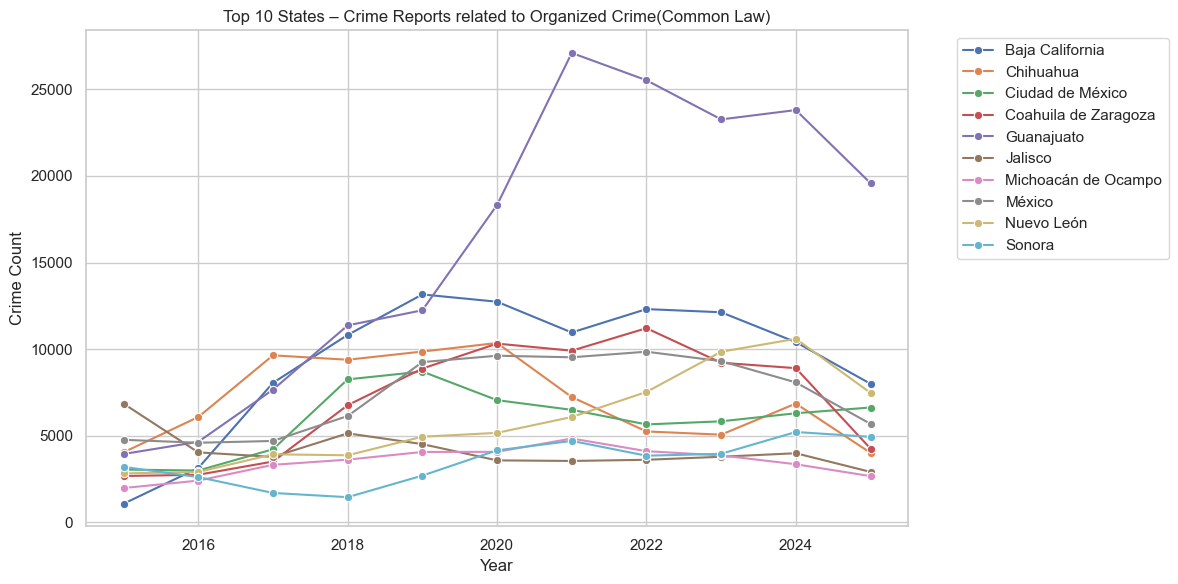

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_fc,
    x='ao',
    y='conteo_delitos',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Crime Reports related to Organized Crime(Common Law)')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


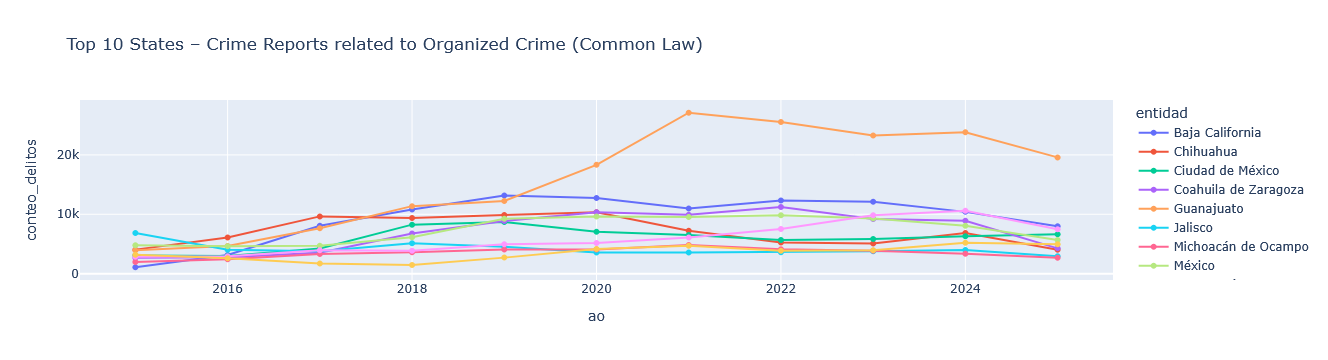

In [40]:
# Create interactive plot

fig = px.line(
    df_top10_fc,
    x='ao',
    y='conteo_delitos',
    color='entidad',
    markers=True,
    title='Top 10 States – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Rates per 100k inhabitants

In [41]:
df_fc_rates = df_fc_yearly.merge(df_pop_yearly.loc[:, ['ao', 'cve_geo', 'poblacion']], on=['cve_geo', 'ao'])
df_fc_rates.head(10)

,entidad,ao,cve_geo,conteo_delitos,poblacion
0,Aguascalientes,2015,1,698.0,1344649
1,Aguascalientes,2016,1,830.0,1367412
2,Aguascalientes,2017,1,1052.0,1389971
3,Aguascalientes,2018,1,1941.0,1413003
4,Aguascalientes,2019,1,2428.0,1436338
5,Aguascalientes,2020,1,2289.0,1456050
6,Aguascalientes,2021,1,1284.0,1472645
7,Aguascalientes,2022,1,2255.0,1491126
8,Aguascalientes,2023,1,2376.0,1510839
9,Aguascalientes,2024,1,2407.0,1530185


In [42]:
df_fc_rates['tasa_por_100k'] = df_fc_rates['conteo_delitos'] / df_fc_rates['poblacion'] * 100000
df_fc_rates.head()

,entidad,ao,cve_geo,conteo_delitos,poblacion,tasa_por_100k
0,Aguascalientes,2015,1,698.0,1344649,51.909457
1,Aguascalientes,2016,1,830.0,1367412,60.698604
2,Aguascalientes,2017,1,1052.0,1389971,75.685032
3,Aguascalientes,2018,1,1941.0,1413003,137.367012
4,Aguascalientes,2019,1,2428.0,1436338,169.040992


In [43]:
top10_rates_fc= df_fc_rates.groupby('entidad')['tasa_por_100k'].sum().nlargest(10).index
df_top10_rates_fc = df_fc_rates[df_fc_rates['entidad'].isin(top10_rates_fc)]
df_top10_rates_fc.entidad.unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Chihuahua', 'Coahuila de Zaragoza', 'Colima', 'Guanajuato',
       'Quintana Roo', 'San Luis Potosí', 'Sonora'], dtype=object)

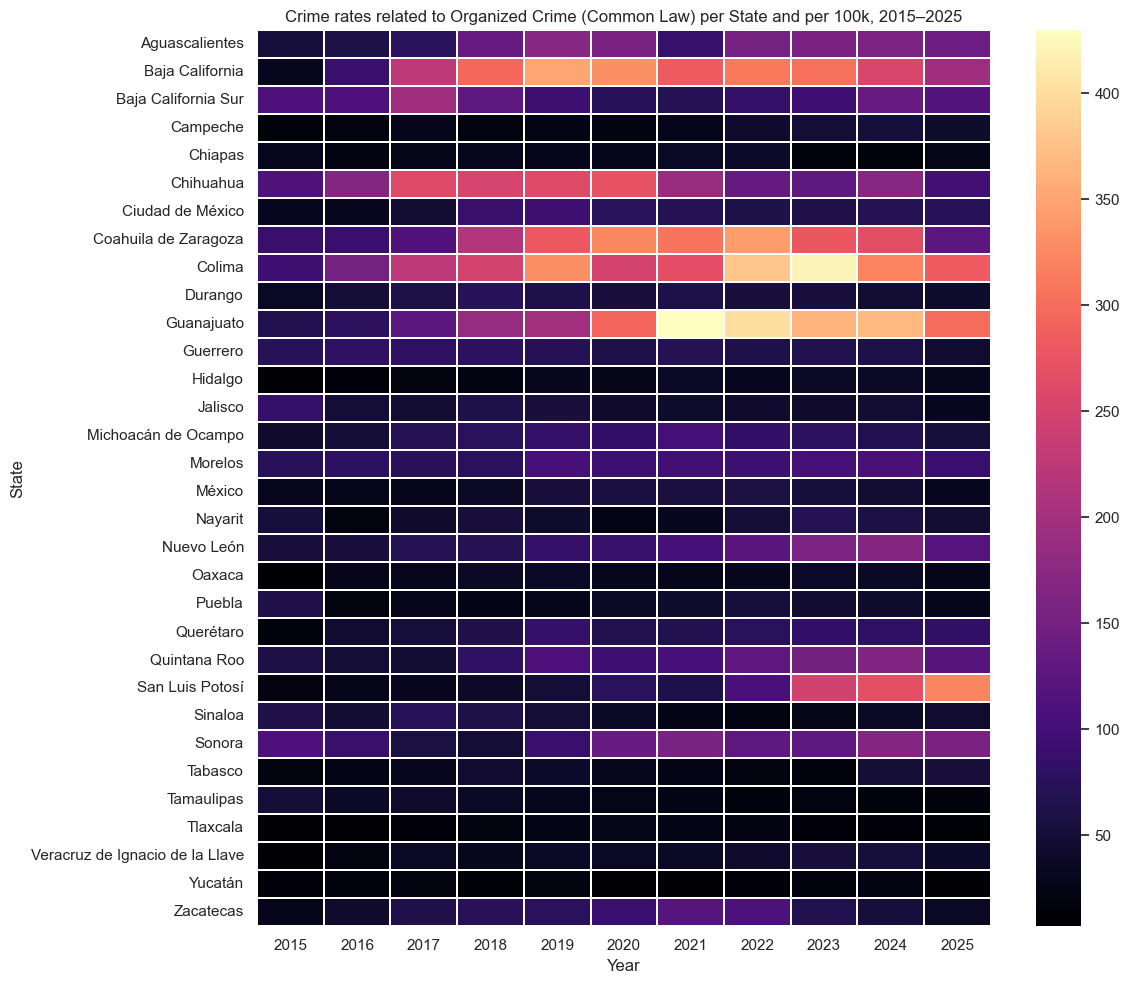

In [44]:
heat_data = df_fc_rates.pivot(index='entidad', columns='ao', values='tasa_por_100k').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime rates related to Organized Crime (Common Law) per State and per 100k, 2015–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

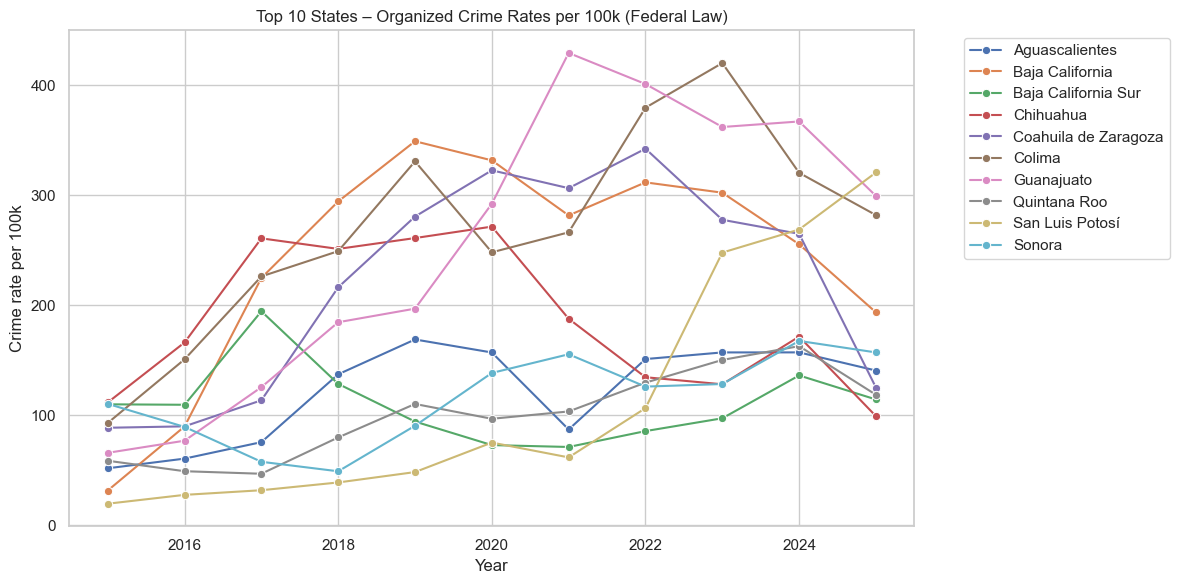

In [47]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_rates_fc,
    x='ao',
    y='tasa_por_100k',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Rates per 100k (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime rate per 100k')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [46]:
# Create interactive plot

fig = px.line(
    df_top10_rates_fc,
    x='ao',
    y='tasa_por_100k',
    color='entidad',
    markers=True,
    title='Top 10 States – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()
